In [1]:
import sys
import matplotlib.pyplot as plt
import numpy as np
import torch
from torchinfo import summary

sys.path.insert(0, "../")
from src.config import CLASS_NAMES, MOTOR_CHANNELS
from src.networks import EEGNet

In [2]:
print(f"Labels: {CLASS_NAMES}")
print(f"Channels: {MOTOR_CHANNELS}")

Labels: ('elbow_flex_ext', 'hand_open_close', 'forearm_sup_pron', 'rest')
Channels: ['FC5', 'FC3', 'FC1', 'FCz', 'FC2', 'FC4', 'FC6', 'C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6', 'CP5', 'CP3', 'CP1', 'CPz', 'CP2', 'CP4', 'CP6']


In [3]:
train_dataset = "../data/processed/dataset_train.npz"
test_dataset = "../data/processed/dataset_test.npz"

## **Load data**

In [4]:
def load_npz_split(path) -> tuple[np.ndarray, np.ndarray, dict]:
    z = np.load(path, allow_pickle=True)
    X = np.asarray(z["X"], dtype=np.float64)
    y = np.asarray(z["y"]).astype(np.int64).ravel()
    meta = {
        "sfreq": float(np.asarray(z["sfreq"]).squeeze()),
        "ch_names": [str(x) for x in np.asarray(z["ch_names"], dtype=object).ravel()],
        "split": str(np.asarray(z["split"]).ravel()[0]),
        "path": path,
    }
    return X, y, meta

X_train, y_train, train_meta = load_npz_split(train_dataset)
X_test, y_test, test_meta = load_npz_split(test_dataset)

In [5]:
print(X_train.shape, y_train.shape)
unique, counts = np.unique(y_train, return_counts=True)
for c, n in zip(unique, counts):
    print(f"  {int(c):d} {CLASS_NAMES[int(c)]}: {int(n)} trials")

(2385, 21, 321) (2385,)
  0 elbow_flex_ext: 766 trials
  1 hand_open_close: 602 trials
  2 forearm_sup_pron: 621 trials
  3 rest: 396 trials


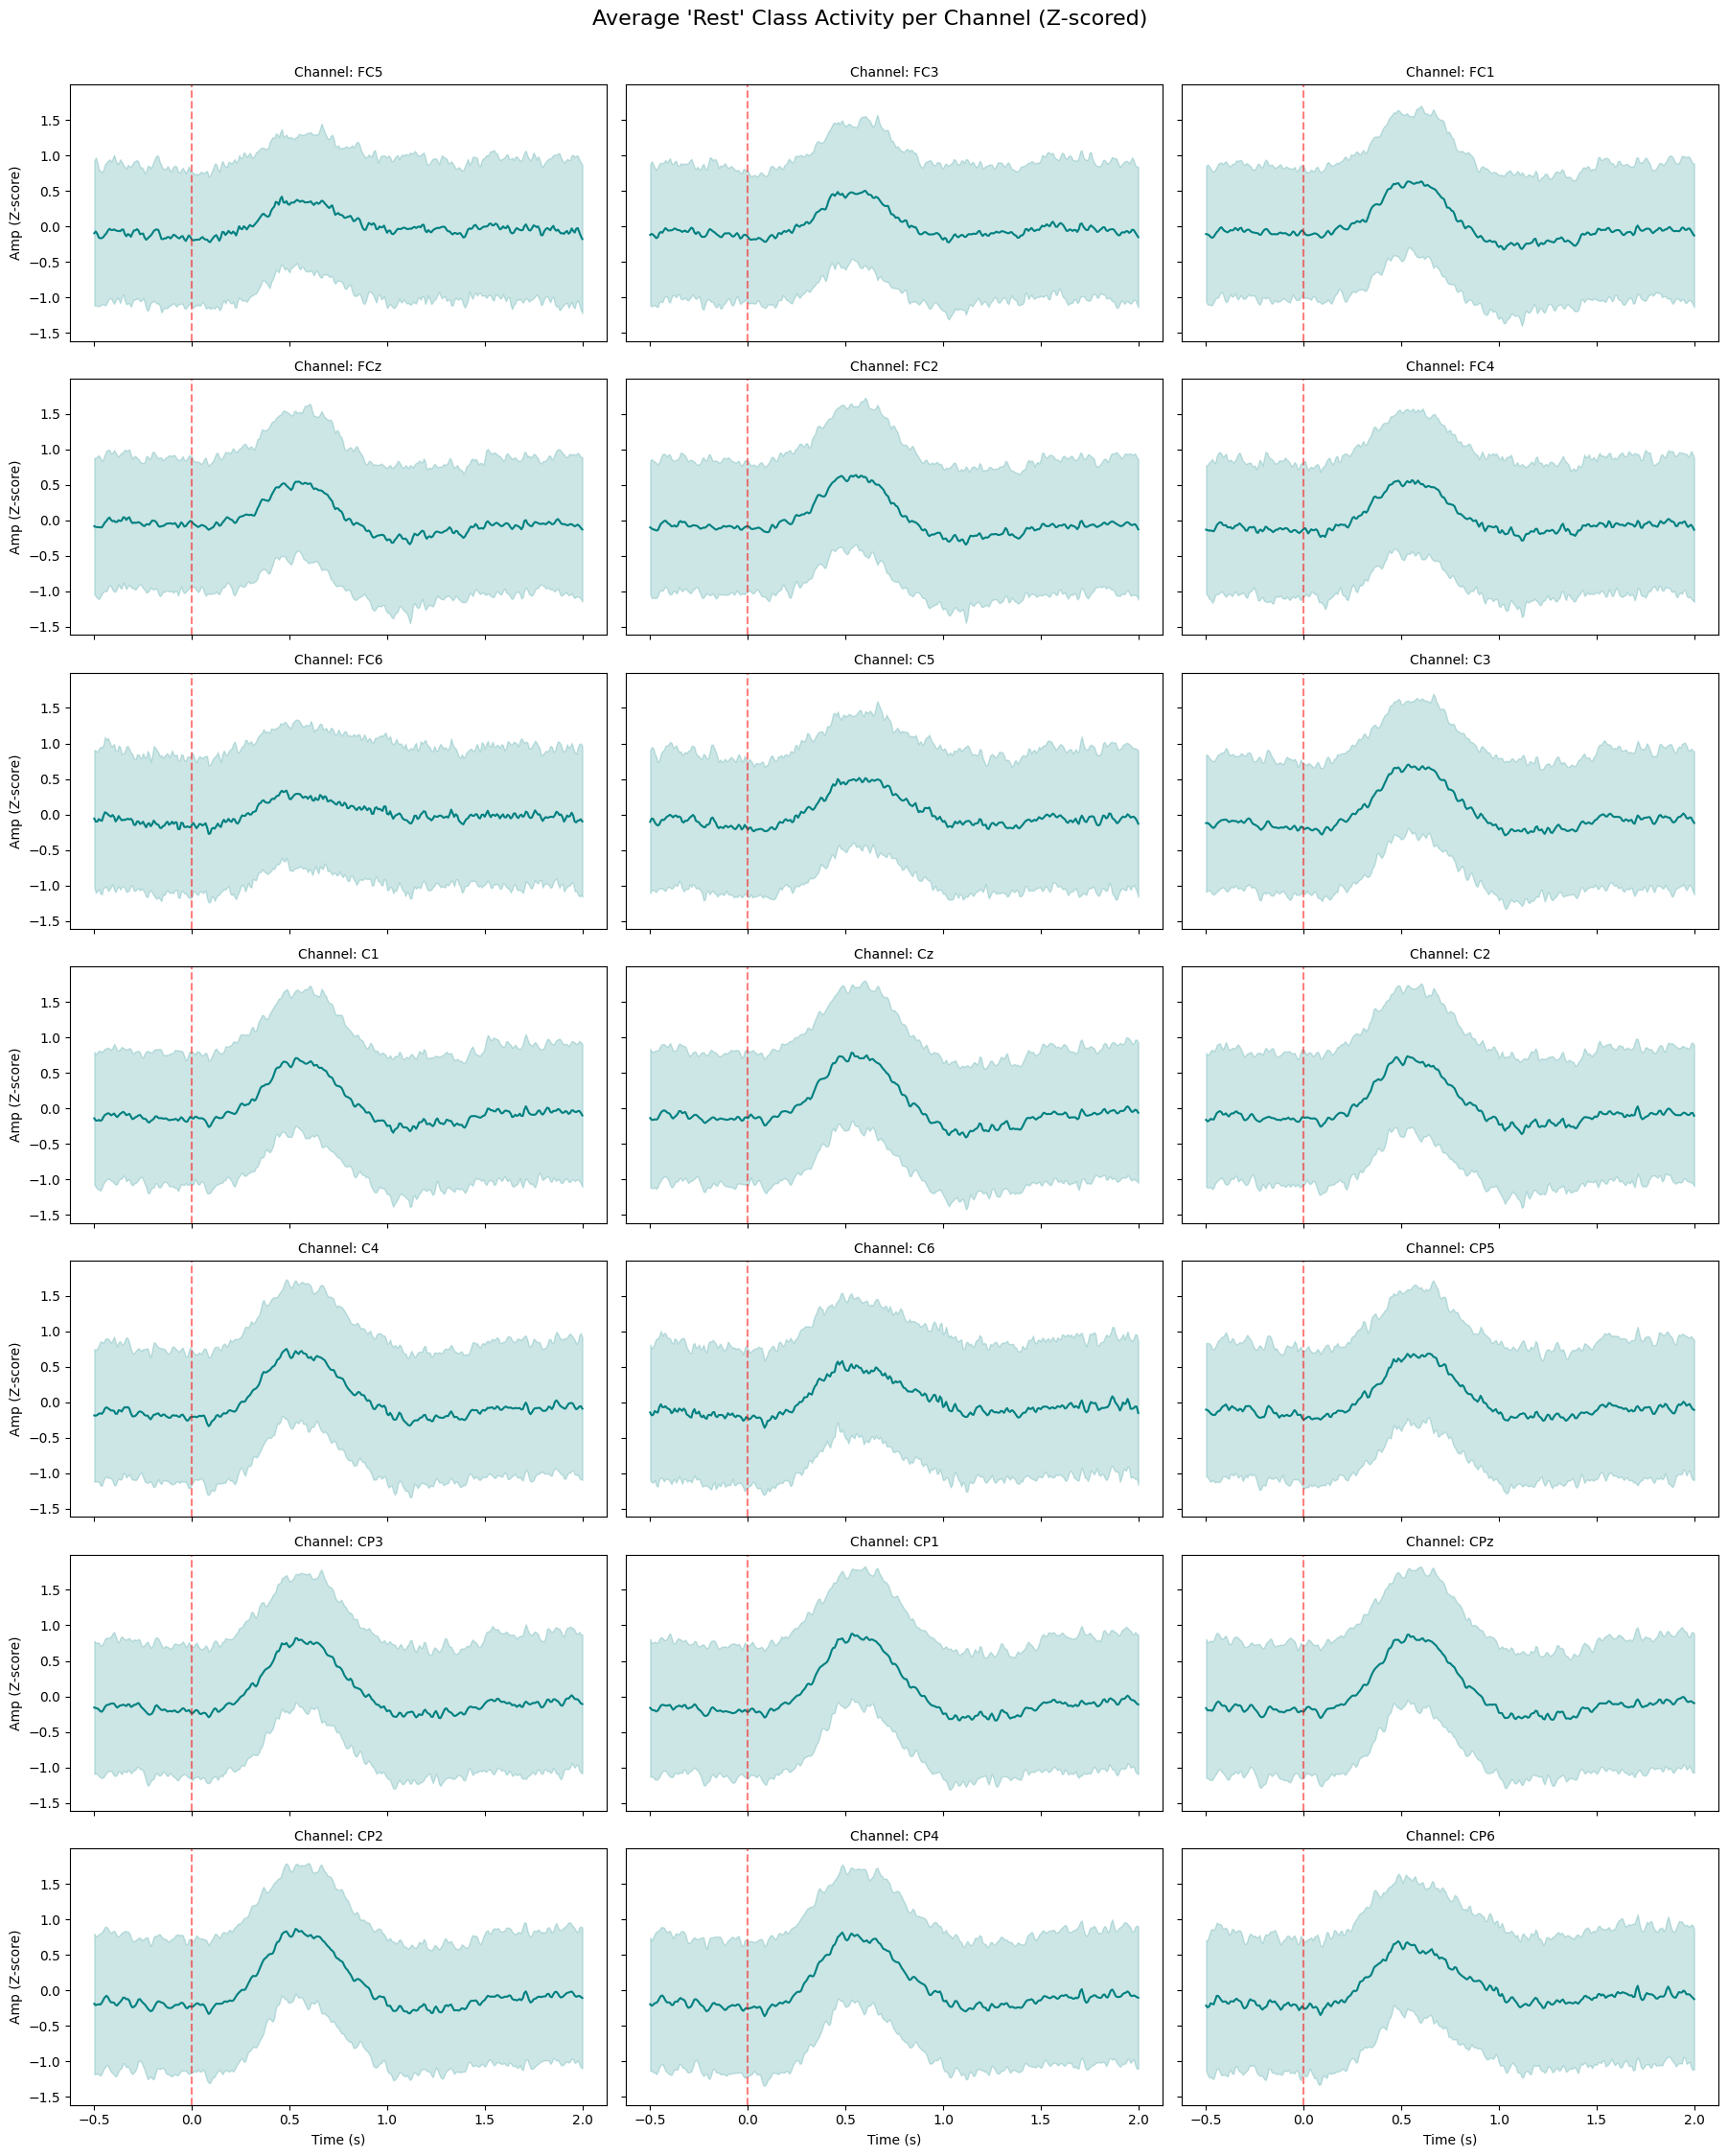

In [6]:
def plot_rest_class_averages(X, y, label, ch_names, sfreq=128.0):
    """
    Plots the average and +/- std shadow for the 'rest' class across all channels.
    
    Parameters:
    X : np.ndarray, shape (n_epochs, n_channels, n_times)
    y : np.ndarray, shape (n_epochs,)
    ch_names : list of str
    sfreq : float, sampling frequency
    """
    rest_idx = np.where(y == label)[0]
    X_rest = X[rest_idx]
    
    # Calculate Mean and STD across epochs (axis 0)
    mean_rest = np.mean(X_rest, axis=0) # (21, 321)
    std_rest = np.std(X_rest, axis=0)   # (21, 321)
    t = np.linspace(-0.5, 2.0, X.shape[2])
    
    fig, axes = plt.subplots(7, 3, figsize=(18, 22), sharex=True, sharey=True)
    axes = axes.flatten()
    
    for i in range(len(ch_names)):
        ax = axes[i]
        ax.plot(t, mean_rest[i], color='teal', lw=1.5, label='Mean Rest')
        ax.fill_between(t, 
                        mean_rest[i] - std_rest[i], 
                        mean_rest[i] + std_rest[i], 
                        color='teal', alpha=0.2, label='±1 STD')
        ax.set_title(f"Channel: {ch_names[i]}", fontsize=10)
        ax.axvline(0, color='red', linestyle='--', alpha=0.5) # Cue onset
        
        if i >= 18: # Bottom row
            ax.set_xlabel('Time (s)')
        if i % 3 == 0: # Left column
            ax.set_ylabel('Amp (Z-score)')

    plt.tight_layout()
    plt.suptitle("Average 'Rest' Class Activity per Channel (Z-scored)", fontsize=16, y=1.02)
    plt.savefig("rest_class_averages.png", dpi=150, bbox_inches='tight')
    plt.show()

plot_rest_class_averages(X_train, y_train, 3, MOTOR_CHANNELS)

### *PLot Event Grand Average*

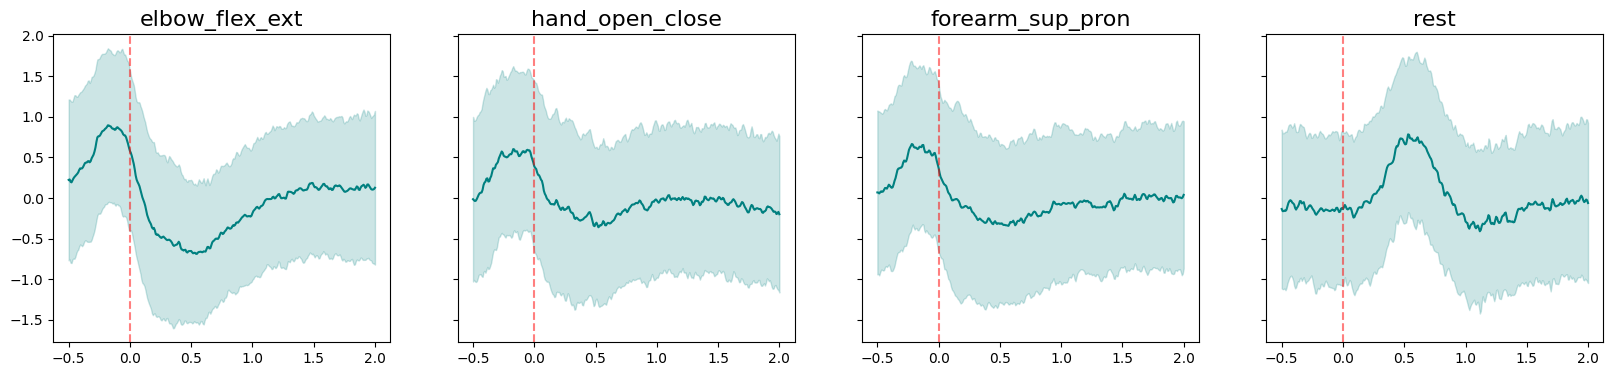

In [7]:
t = np.linspace(-0.5, 2.0, X_train.shape[2])
fig, axes = plt.subplots(1, 4, figsize=(20, 4), sharex=True, sharey=True)
axes = axes.flatten()

selected_channel = "Cz"
channel_idx = MOTOR_CHANNELS.index(selected_channel)

for idx, name in enumerate(CLASS_NAMES):
    events = X_train[y_train == idx]
    mean = np.mean(events, axis=0)[channel_idx]
    std = np.std(events, axis=0)[channel_idx]

    ax = axes[idx]
    ax.plot(t, mean, color='teal', lw=1.5, label=name)
    ax.fill_between(t, 
                    mean - std, 
                    mean + std, 
                    color='teal', alpha=0.2, label='±1 STD')
    ax.set_title(name, fontsize=16)
    ax.axvline(0, color='red', linestyle='--', alpha=0.5)




### **Visualizing input tensor**

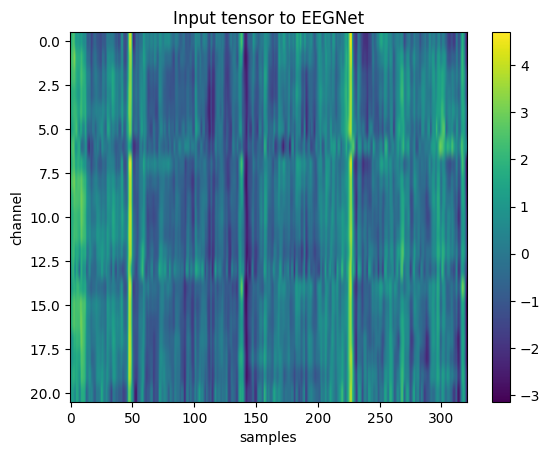

In [8]:
plt.figure()
plt.imshow(X_train[0],  aspect='auto')
plt.title("Input tensor to EEGNet")
plt.xlabel("samples")
plt.ylabel("channel")
plt.colorbar()
plt.show()

## **Build Model**

In this case we are going to build a deep learning model that will learn the temporal dynamics of the different channels for each event type.

In [9]:
n_channels=21 
n_classes=4 
sfreq=128
F1=8
D=4
F2=16
dropout_rate=0.5

net = EEGNet(
    n_channels, n_classes, sfreq, F1, D, F2, dropout_rate
)
summary(net, input_size=(1, 1, 21, 321))

Layer (type:depth-idx)                   Output Shape              Param #
EEGNet                                   [1, 4]                    --
├─Sequential: 1-1                        [1, 8, 21, 322]           --
│    └─Conv2d: 2-1                       [1, 8, 21, 322]           512
│    └─BatchNorm2d: 2-2                  [1, 8, 21, 322]           16
├─Sequential: 1-2                        [1, 32, 1, 80]            --
│    └─Conv2d: 2-3                       [1, 32, 1, 322]           672
│    └─BatchNorm2d: 2-4                  [1, 32, 1, 322]           64
│    └─ELU: 2-5                          [1, 32, 1, 322]           --
│    └─AvgPool2d: 2-6                    [1, 32, 1, 80]            --
│    └─Dropout: 2-7                      [1, 32, 1, 80]            --
├─Sequential: 1-3                        [1, 16, 1, 10]            --
│    └─Conv2d: 2-8                       [1, 32, 1, 81]            512
│    └─Conv2d: 2-9                       [1, 16, 1, 81]            512
│    └─Batc

## **Train model**

### *Build Dataset*

In [ ]:
import torch
from torch.utils.data import TensorDataset, DataLoader

X_tensor = torch.from_numpy(X_train).float()
y_tensor = torch.from_numpy(y_train).long()

# Add the 1-depth dimension for the Conv2d layer: (Batch, 1, 21, 321)
X_tensor = X_tensor.unsqueeze(1)

X_test_tensor = torch.from_numpy(X_test).float()
y_test_tensor = torch.from_numpy(y_test).long()

# Add the 1-depth dimension for the Conv2d layer: (Batch, 1, 21, 321)
X_test_tensor = X_test_tensor.unsqueeze(1)

# Create DataLoader
train_dataset = TensorDataset(X_tensor, y_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

# Create DataLoader
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=True)

### *Training Loop*

In [12]:
import torch.optim as optim
import torch.nn as nn
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = net.to(device)

counts = torch.tensor([766, 602, 621, 396], dtype=torch.float)
weights = 1.0 / counts
weights = weights / weights.sum() # Normalize
weights = weights.to(device)

num_epochs = 100
criterion = nn.CrossEntropyLoss(weight=weights, label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.01)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    # tqdm creates the progress bar
    pbar = tqdm(enumerate(loader), total=len(loader), desc="Training", leave=False)
    
    for batch_idx, (inputs, labels) in pbar:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
        # Update the progress bar text
        pbar.set_postfix({
            'loss': f'{running_loss/(batch_idx+1):.4f}',
            'acc': f'{100.*correct/total:.2f}%'
        })
        
    return running_loss / len(loader), 100. * correct / total

# Storage for plotting
history = {
    'train_loss': [], 
    'train_acc': [], 
    'val_loss': [], 
    'val_acc': []
}

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    
    with torch.no_grad():
        for batch_raw, labels in test_loader:  # Use your test/validation loader
            batch_raw, labels = batch_raw.to(device),  labels.to(device)
            
            outputs = model(batch_raw)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item() * labels.size(0)
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()
            
    epoch_val_loss = val_loss / val_total
    epoch_val_acc = 100. * val_correct / val_total
    
    # Store history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(epoch_val_loss)
    history['val_acc'].append(epoch_val_acc)
    
    # Update learning rate based on the validation loss to avoid overfitting/stalling
    scheduler.step(epoch_val_loss)
    
    current_lr = optimizer.param_groups[0]['lr']
    print(f"Epoch {epoch+1:02d} | Train Acc: {train_acc:.2f}% | Val Acc: {epoch_val_acc:.2f}% | LR: {current_lr:.6f}")

/tmp/ipykernel_114829/3193843299.py:87: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  scheduler.step(epoch_val_loss)


Epoch 01 | Train Acc: 48.05% | Val Acc: 52.49% | LR: 0.000999


Epoch 02 | Train Acc: 49.60% | Val Acc: 51.54% | LR: 0.000999


Epoch 03 | Train Acc: 50.73% | Val Acc: 50.83% | LR: 0.000999


Epoch 04 | Train Acc: 51.99% | Val Acc: 52.49% | LR: 0.000999


...

Epoch 96 | Train Acc: 65.03% | Val Acc: 64.61% | LR: 0.000999


Epoch 97 | Train Acc: 64.40% | Val Acc: 63.90% | LR: 0.000999


Epoch 98 | Train Acc: 65.74% | Val Acc: 62.47% | LR: 0.000999


Epoch 99 | Train Acc: 65.07% | Val Acc: 65.08% | LR: 0.000999


Epoch 100 | Train Acc: 63.69% | Val Acc: 63.90% | LR: 0.000999


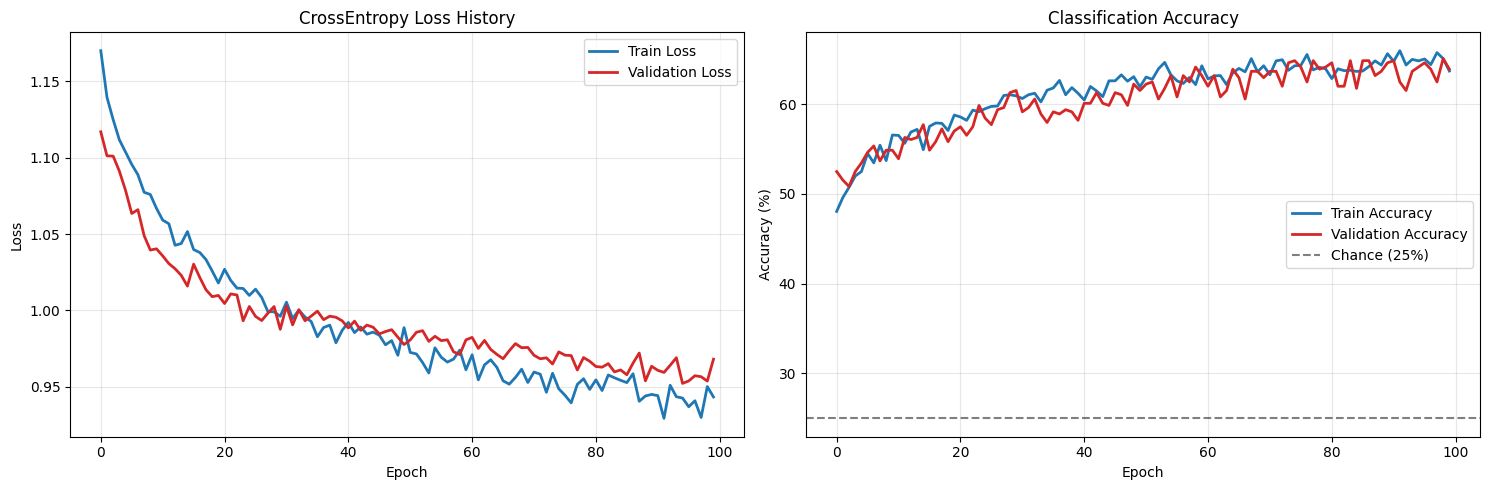

In [13]:
from src.utils import plot_history

plot_history(history)

## **Evaluate the performance**

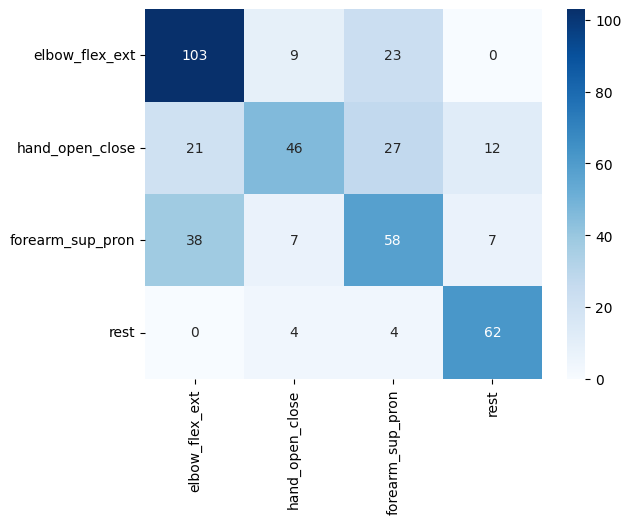

In [14]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

def plot_cm(model, loader, device):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for inputs, labels in loader:
            outputs = model(inputs.to(device))
            all_preds.extend(outputs.argmax(1).cpu().numpy())
            all_labels.extend(labels.numpy())
    
    cm = confusion_matrix(all_labels, all_preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.show()

    return cm, all_labels, all_preds

cm, labels, preds = plot_cm(model, test_loader, device)

In [15]:
diff = np.array(preds) == np.array(labels)
correct = np.where(diff == True)[0]
test_accuracy = len(correct) / len(preds)
print(f"Test Accuracy for the model is: {test_accuracy}")

Test Accuracy for the model is: 0.6389548693586699


## View Model Insights before Classification

Extracting bottleneck features from test set...
Running t-SNE (this may take a minute)...


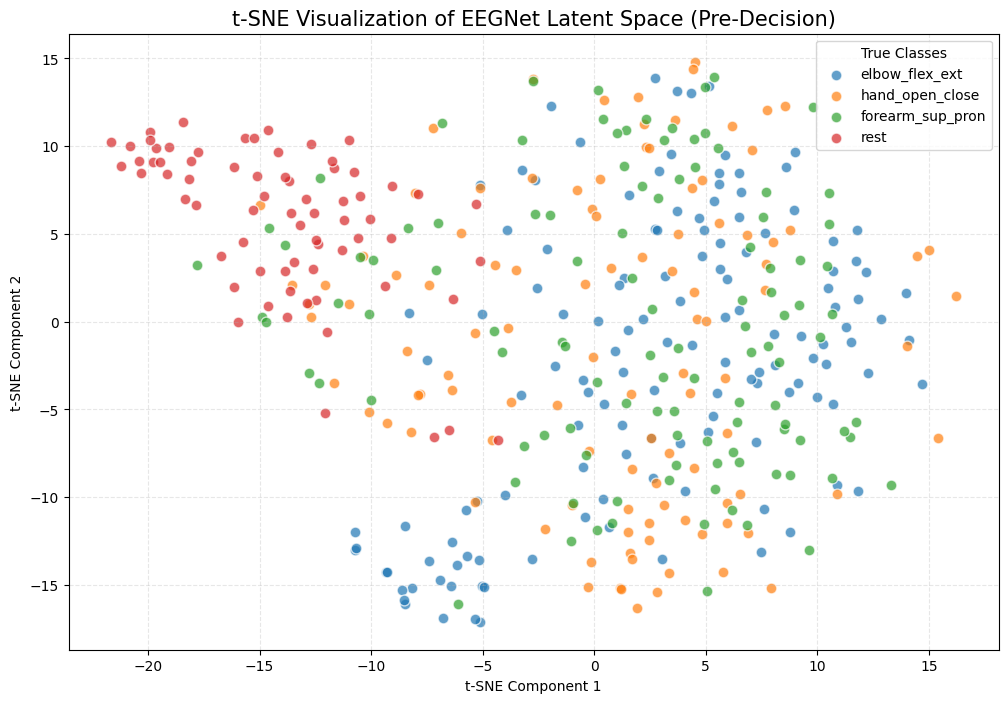

In [ ]:
from sklearn.manifold import TSNE

def get_bottleneck_features(model, loader, device):
    model.eval()
    features = []
    labels_list = []
    
    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            
            # Step-by-step forward pass to stop before the Linear layer
            x = model.temporal_conv(inputs)
            x = model.depthwise_conv(x)
            x = model.temporal_summary(x)
            x = torch.flatten(x, 1) # This is our feature vector (e.g., size 160)
            
            features.append(x.cpu().numpy())
            labels_list.append(labels.numpy())
            
    return np.concatenate(features), np.concatenate(labels_list)

def plot_feature_clusters(model, test_loader, device, class_names):
    # Extract features
    print("Extracting bottleneck features from test set...")
    features, labels = get_bottleneck_features(model, test_loader, device)
    
    # Apply t-SNE
    print("Running t-SNE (this may take a minute)...")
    tsne = TSNE(n_components=2, perplexity=30, max_iter=1000, random_state=42)
    features_2d = tsne.fit_transform(features)
    
    plt.figure(figsize=(12, 8))
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'] # Distinct professional colors
    
    for i, class_name in enumerate(class_names):
        indices = np.where(labels == i)
        plt.scatter(
            features_2d[indices, 0], 
            features_2d[indices, 1], 
            c=colors[i], 
            label=class_name,
            alpha=0.7, 
            edgecolors='w', 
            s=60
        )
    
    plt.title("t-SNE Visualization of EEGNet Latent Space (Pre-Decision)", fontsize=15)
    plt.xlabel("t-SNE Component 1")
    plt.ylabel("t-SNE Component 2")
    plt.legend(title="True Classes", loc='best')
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.show()


plot_feature_clusters(net, test_loader, device, CLASS_NAMES)